# Control-Flow Perspective — Drift Exploration

Simple visual tour of `data/control-flow/control_flow_001.xes`. Drift change
points are read straight from the log's `drift_info` header. Single-time plots
use vertical splitter lines at every drift; the per-drift comparison cell at
the bottom is run by editing `SELECTED_DRIFT` manually.

Control-flow drifts show up as new/disappearing **trace variants**, changes in
**activity composition**, and rewired **directly-follows pairs**.

In [1]:
import json
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_hex

import pm4py

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

project_root = Path.cwd()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent

log_path = project_root / "data" / "control-flow" / "control_flow_001.xes"

# Pre/post window length (days on each side of the drift) for the comparison cell.
WINDOW_DAYS = 30


def read_drift_info(xes_path):
    """Read the log-level `drift_info` JSON attribute without loading the full log."""
    ns = "{http://www.xes-standard.org/}"
    for event, elem in ET.iterparse(str(xes_path), events=("start", "end")):
        if event == "end" and elem.tag == f"{ns}string" and elem.attrib.get("key") == "drift_info":
            return json.loads(elem.attrib["value"])
        if event == "start" and elem.tag == f"{ns}trace":
            break
    return []


_drift_info = read_drift_info(log_path)
DRIFT_TIMESTAMPS = [pd.Timestamp(d["change_point_timestamp"]) for d in _drift_info]
DRIFT_LABELS = [d["drift_id"] for d in _drift_info]
DRIFT_NOTES = {
    d["drift_id"]: f"{d['drift_type']} · {d['subtype']}" for d in _drift_info
}

print(f"loaded {len(DRIFT_TIMESTAMPS)} drifts:")
for ts, lbl, info in zip(DRIFT_TIMESTAMPS, DRIFT_LABELS, _drift_info):
    cd = info.get("change_details", {})
    extras = []
    if cd.get("activities_added"):
        extras.append(f"+{cd['activities_added']}")
    if cd.get("activities_deleted"):
        extras.append(f"-{cd['activities_deleted']}")
    if cd.get("operator_swaps"):
        extras.append(", ".join(f"{s['from']}→{s['to']}" for s in cd["operator_swaps"]))
    if cd.get("variant_count_before") is not None and cd.get("variant_count_after") is not None:
        extras.append(f"variants {cd['variant_count_before']}→{cd['variant_count_after']}")
    print(f"  {lbl}  {ts}  ({DRIFT_NOTES[lbl]})  {' · '.join(extras)}")

loaded 2 drifts:
  d01  2020-06-06 21:37:28.876168+00:00  (sudden · tree_mutation)  -['e'] · sequence→or · variants 1→4
  d02  2020-10-14 12:43:21.339588+00:00  (sudden · tree_mutation)  +['e'] · variants 4→6


## 1 · Load & summary

In [2]:
df = pm4py.read_xes(str(log_path))
df = df.rename(
    columns={
        "case:concept:name": "case_id",
        "concept:name": "activity",
        "time:timestamp": "timestamp",
    }
)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values(["case_id", "timestamp"]).reset_index(drop=True)
df["week"] = df["timestamp"].dt.to_period("W").dt.start_time

# Trace variant = ordered activity sequence per case.
case_variant = (
    df.groupby("case_id")["activity"]
    .apply(lambda s: ",".join(s))
    .rename("variant")
)
case_start = df.groupby("case_id")["timestamp"].min().rename("case_start")
case_length = df.groupby("case_id").size().rename("case_length")
cases_df = pd.concat([case_start, case_length, case_variant], axis=1).reset_index()
cases_df["week"] = cases_df["case_start"].dt.to_period("W").dt.start_time

activities_sorted = sorted(df["activity"].unique())
variants_sorted = (
    cases_df["variant"].value_counts().index.tolist()
)  # ordered most-frequent first

# Stable colour palettes
VARIANT_COLORS = {
    v: to_hex(c)
    for v, c in zip(variants_sorted, sns.color_palette("tab20", n_colors=max(len(variants_sorted), 1)))
}
ACTIVITY_COLORS = {
    a: to_hex(c)
    for a, c in zip(activities_sorted, sns.color_palette("Set2", n_colors=max(len(activities_sorted), 1)))
}

print(f"events:        {len(df):,}")
print(f"cases:         {df['case_id'].nunique():,}")
print(f"activities:    {df['activity'].nunique():,}")
print(f"trace variants:{cases_df['variant'].nunique():,}")
print(f"time span:     {df['timestamp'].min()} → {df['timestamp'].max()}")
print()
print("top 10 variants:")
for v, n in cases_df["variant"].value_counts().head(10).items():
    print(f"  {n:5d}  {v}")
df.head()

/Users/bd/Projects/thesis/pm4py/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


/Users/bd/Projects/thesis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



parsing log, completed traces ::   0%|          | 0/6000 [00:00<?, ?it/s]


parsing log, completed traces ::  18%|█▊        | 1103/6000 [00:00<00:00, 10291.48it/s]


parsing log, completed traces ::  42%|████▏     | 2523/6000 [00:00<00:00, 12519.33it/s]

...


parsing log, completed traces :: 100%|██████████| 6000/6000 [00:00<00:00, 12904.53it/s]

/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_47510/4177760447.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = df["timestamp"].dt.to_period("W").dt.start_time


events:        32,669
cases:         6,000
activities:    6
trace variants:11
time span:     2020-01-01 02:29:50.783222+00:00 → 2021-02-12 06:31:58.011500+00:00

top 10 variants:
   2317  c,a,d,f,b,e
   1432  c,a,d,f,b
    810  c,a,d,f,e,b
    716  a,d,f,e
    357  a,c,d,f,b
    185  a,c,d,f,e,b
     59  a,d,c,f,b
     51  a,d,f,c,b
     40  a,d,c,f,e,b
     19  a,d,f,c,e,b


/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_47510/4177760447.py:22: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cases_df["week"] = cases_df["case_start"].dt.to_period("W").dt.start_time


,event:id,activity,start_timestamp,timestamp,event:duration_min,org:resource,org:role,case_id,case:case_type,case:amount,case:region,week
0,evt_00000001,c,2020-01-01 02:18:13.268219+00:00,2020-01-01 02:29:50.783222+00:00,11.625250,res_002,role_02,case_000001,type_03,879.23,DE-HE,2019-12-30
1,evt_00000002,a,2020-01-01 02:33:22.393487+00:00,2020-01-01 02:42:07.866616+00:00,8.757885,res_003,role_03,case_000001,type_03,879.23,DE-HE,2019-12-30
2,evt_00000003,d,2020-01-01 02:45:39.184011+00:00,2020-01-01 03:00:24.934841+00:00,14.762514,res_005,role_02,case_000001,type_03,879.23,DE-HE,2019-12-30
3,evt_00000004,f,2020-01-01 03:01:09.821163+00:00,2020-01-01 03:02:09.727114+00:00,0.998433,res_010,role_01,case_000001,type_03,879.23,DE-HE,2019-12-30
4,evt_00000005,b,2020-01-01 03:03:46.504848+00:00,2020-01-01 03:24:47.056781+00:00,21.009199,res_007,role_01,case_000001,type_03,879.23,DE-HE,2019-12-30


## 2 · Global control-flow overview

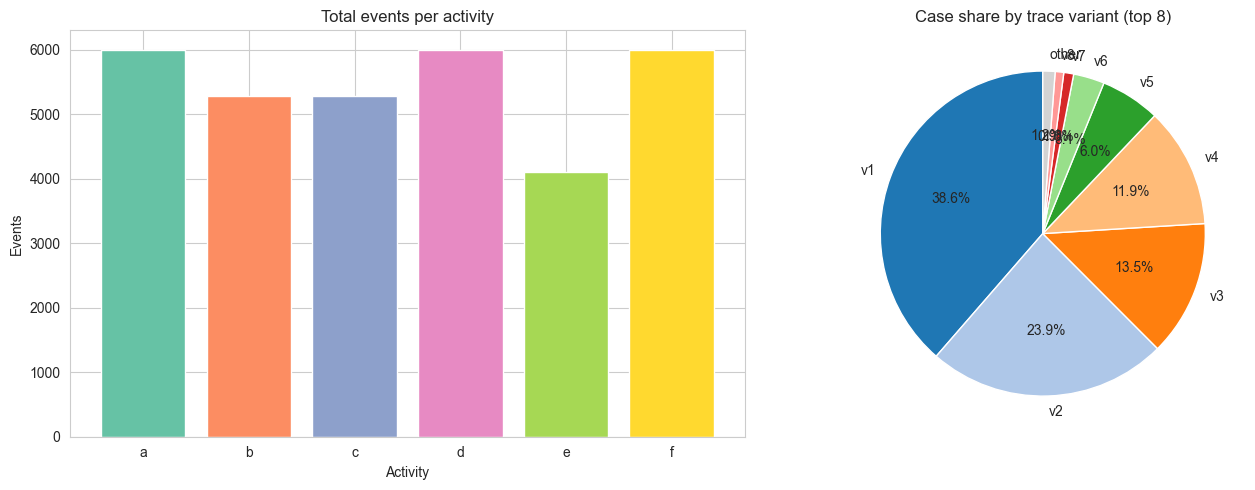

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

act_counts = df["activity"].value_counts().reindex(activities_sorted)
axes[0].bar(act_counts.index, act_counts.values,
            color=[ACTIVITY_COLORS[a] for a in act_counts.index])
axes[0].set_title("Total events per activity")
axes[0].set_xlabel("Activity")
axes[0].set_ylabel("Events")

variant_counts = cases_df["variant"].value_counts()
top_n = 8
top = variant_counts.head(top_n)
other = variant_counts.iloc[top_n:].sum()
pie_values = list(top.values) + ([other] if other > 0 else [])
pie_labels = [f"v{i + 1}" for i in range(len(top))] + (["other"] if other > 0 else [])
pie_colors = [VARIANT_COLORS[v] for v in top.index] + (["lightgray"] if other > 0 else [])
axes[1].pie(pie_values, labels=pie_labels, autopct="%1.1f%%",
            colors=pie_colors, startangle=90)
axes[1].set_title(f"Case share by trace variant (top {top_n})")

plt.tight_layout()
plt.show()

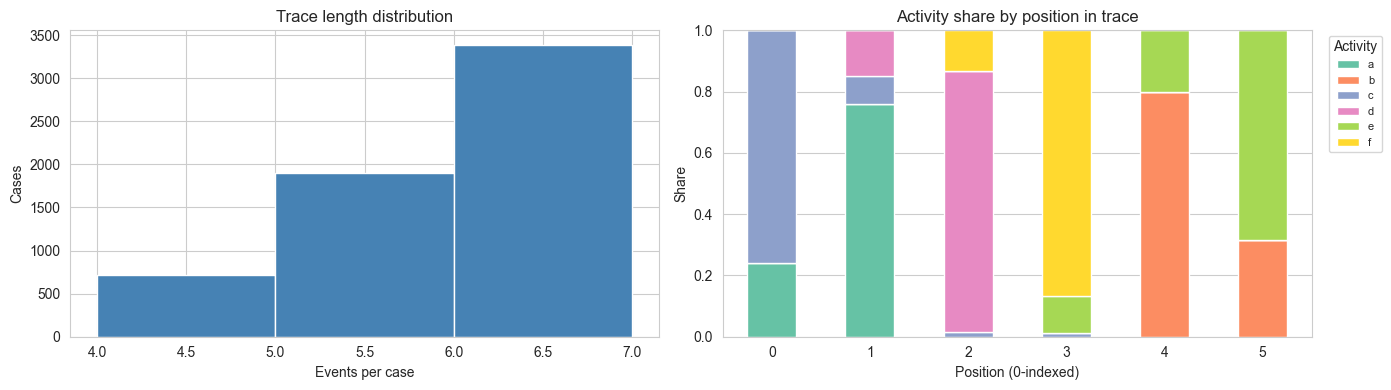

In [4]:
# Trace-length distribution and per-activity position in trace
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(cases_df["case_length"], bins=range(cases_df["case_length"].min(),
             cases_df["case_length"].max() + 2),
             color="steelblue", edgecolor="white")
axes[0].set_title("Trace length distribution")
axes[0].set_xlabel("Events per case")
axes[0].set_ylabel("Cases")

df_pos = df.copy()
df_pos["pos"] = df_pos.groupby("case_id").cumcount()
pos_act = pd.crosstab(df_pos["pos"], df_pos["activity"]).reindex(
    columns=activities_sorted, fill_value=0
)
pos_share = pos_act.div(pos_act.sum(axis=1), axis=0)
pos_share.plot(kind="bar", stacked=True, ax=axes[1],
               color=[ACTIVITY_COLORS[a] for a in pos_share.columns])
axes[1].set_title("Activity share by position in trace")
axes[1].set_xlabel("Position (0-indexed)")
axes[1].set_ylabel("Share")
axes[1].legend(title="Activity", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[1].set_xticks(range(len(pos_share)))
axes[1].set_xticklabels(pos_share.index, rotation=0)

plt.tight_layout()
plt.show()

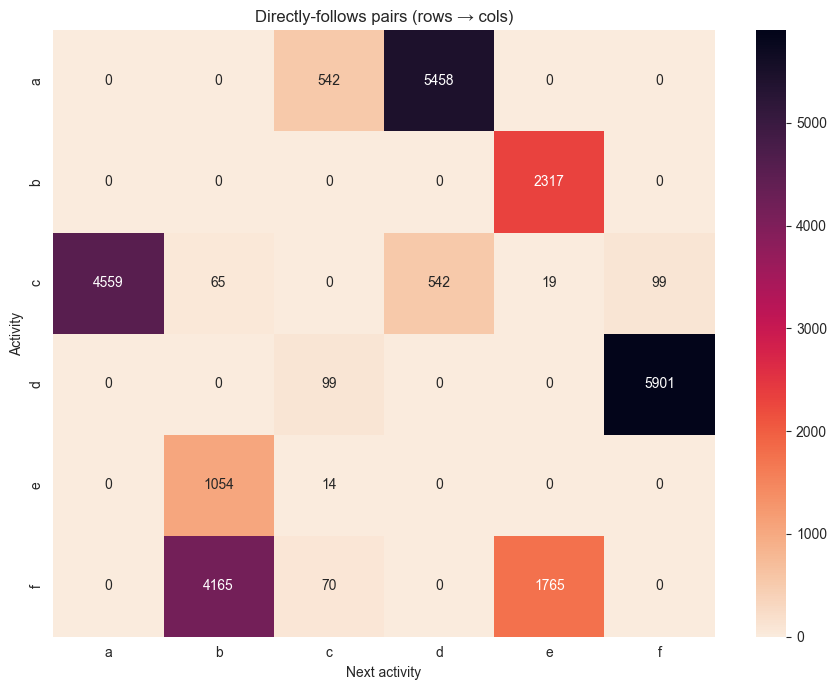

In [5]:
# Directly-follows matrix (full log)
df_pairs = df.copy()
df_pairs["next_activity"] = df_pairs.groupby("case_id")["activity"].shift(-1)
pairs = df_pairs.dropna(subset=["next_activity"])
dfg = pd.crosstab(pairs["activity"], pairs["next_activity"]).reindex(
    index=activities_sorted, columns=activities_sorted, fill_value=0
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(dfg, annot=True, fmt="d", cmap="rocket_r", ax=ax)
ax.set_title("Directly-follows pairs (rows → cols)")
ax.set_xlabel("Next activity")
ax.set_ylabel("Activity")
plt.tight_layout()
plt.show()

## 3 · Time series with drift splitter lines

Every drift change point is drawn as a vertical line on these single-plot
charts so shifts in variant mix, activity composition, and trace structure are
easy to spot.

variant key:
  v1: c,a,d,f,b,e
  v2: c,a,d,f,b
  v3: c,a,d,f,e,b
  v4: a,d,f,e
  v5: a,c,d,f,b
  v6: a,c,d,f,e,b
  v7: a,d,c,f,b
  v8: a,d,f,c,b


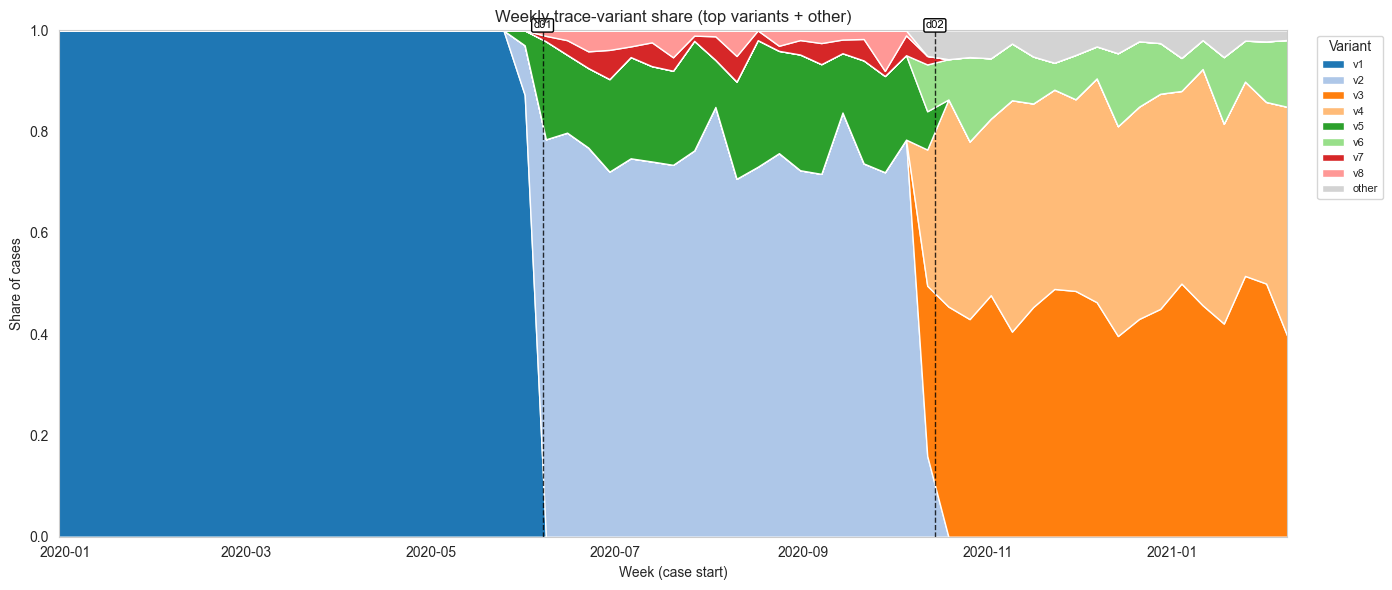

In [6]:
def _draw_drift_lines(ax, *, color="black", label_color="black"):
    ymax = ax.get_ylim()[1]
    for ts, lbl in zip(DRIFT_TIMESTAMPS, DRIFT_LABELS):
        ax.axvline(ts, color=color, linestyle="--", linewidth=1.0, alpha=0.8)
        ax.text(
            ts,
            ymax,
            lbl,
            ha="center",
            va="bottom",
            fontsize=8,
            color=label_color,
            bbox=dict(facecolor="white", edgecolor=color, boxstyle="round,pad=0.15"),
        )


# Weekly variant share (top variants explicitly, rest folded into "other")
top_n = 8
top_variants = cases_df["variant"].value_counts().head(top_n).index.tolist()
cases_df["variant_bucket"] = cases_df["variant"].where(cases_df["variant"].isin(top_variants), "other")

weekly_variants = (
    cases_df.groupby(["week", "variant_bucket"]).size()
    .unstack(fill_value=0)
)
bucket_order = top_variants + (["other"] if "other" in weekly_variants.columns else [])
weekly_variants = weekly_variants.reindex(columns=bucket_order, fill_value=0).sort_index()
weekly_share = weekly_variants.div(weekly_variants.sum(axis=1), axis=0).fillna(0)

variant_labels = [f"v{i + 1}" for i in range(len(top_variants))] + (
    ["other"] if "other" in bucket_order else []
)
bucket_colors = [VARIANT_COLORS[v] for v in top_variants] + (
    ["lightgray"] if "other" in bucket_order else []
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    weekly_share.index,
    weekly_share.T.values,
    labels=variant_labels,
    colors=bucket_colors,
)
ax.set_title("Weekly trace-variant share (top variants + other)")
ax.set_xlabel("Week (case start)")
ax.set_ylabel("Share of cases")
ax.set_xlim(weekly_share.index.min(), weekly_share.index.max())
ax.set_ylim(0, 1)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    ncol=1,
    title="Variant",
)
_draw_drift_lines(ax)
# Mini legend mapping v1..vN to actual variant strings
print("variant key:")
for label, v in zip(variant_labels, top_variants + (["other"] if "other" in bucket_order else [])):
    if v == "other":
        continue
    print(f"  {label}: {v}")
plt.tight_layout()
plt.show()

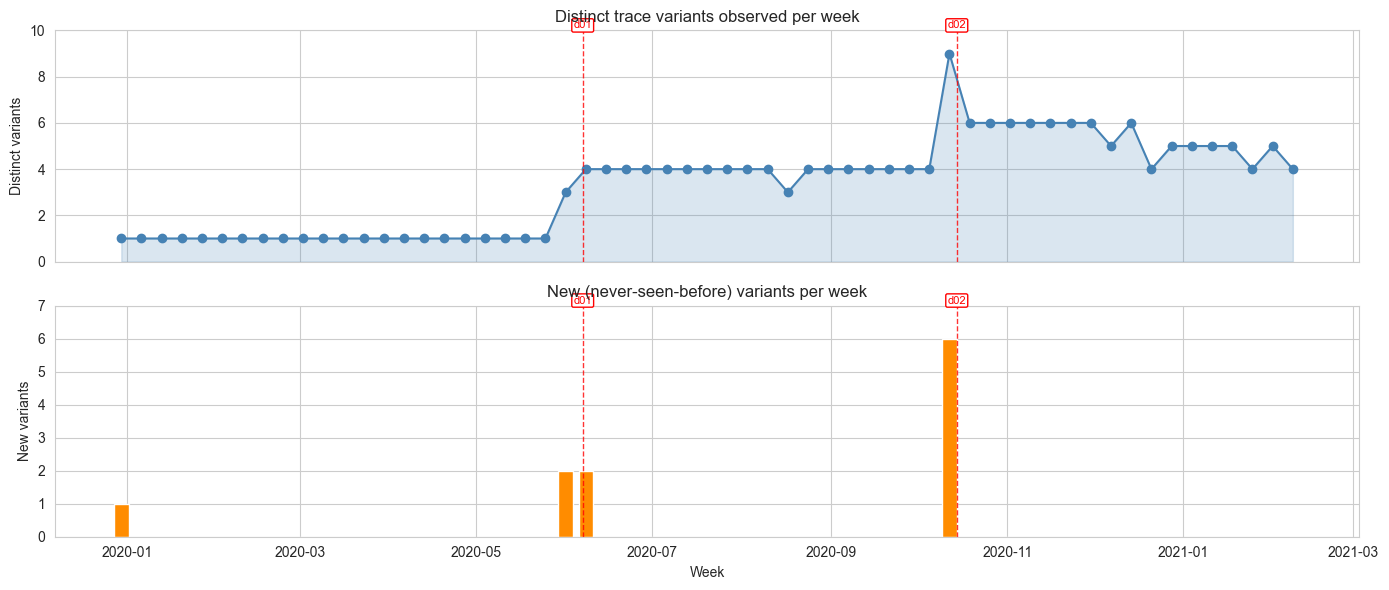

In [7]:
# Distinct trace variants observed per week + new variants emerging
weekly_variants_seen = cases_df.groupby("week")["variant"].nunique()

seen = set()
weekly_new = []
for week, group in cases_df.sort_values("case_start").groupby("week"):
    new_this_week = set(group["variant"].unique()) - seen
    weekly_new.append((week, len(new_this_week)))
    seen.update(group["variant"].unique())
weekly_new_df = pd.DataFrame(weekly_new, columns=["week", "new_variants"]).set_index("week")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(weekly_variants_seen.index, weekly_variants_seen.values,
             marker="o", color="steelblue", linewidth=1.5)
axes[0].fill_between(weekly_variants_seen.index, weekly_variants_seen.values,
                     alpha=0.2, color="steelblue")
axes[0].set_title("Distinct trace variants observed per week")
axes[0].set_ylabel("Distinct variants")
axes[0].set_ylim(0, weekly_variants_seen.max() + 1)
_draw_drift_lines(axes[0], color="red", label_color="red")

axes[1].bar(weekly_new_df.index, weekly_new_df["new_variants"],
            width=5, color="darkorange", edgecolor="white")
axes[1].set_title("New (never-seen-before) variants per week")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("New variants")
axes[1].set_ylim(0, max(weekly_new_df["new_variants"].max() + 1, 1))
_draw_drift_lines(axes[1], color="red", label_color="red")

plt.tight_layout()
plt.show()

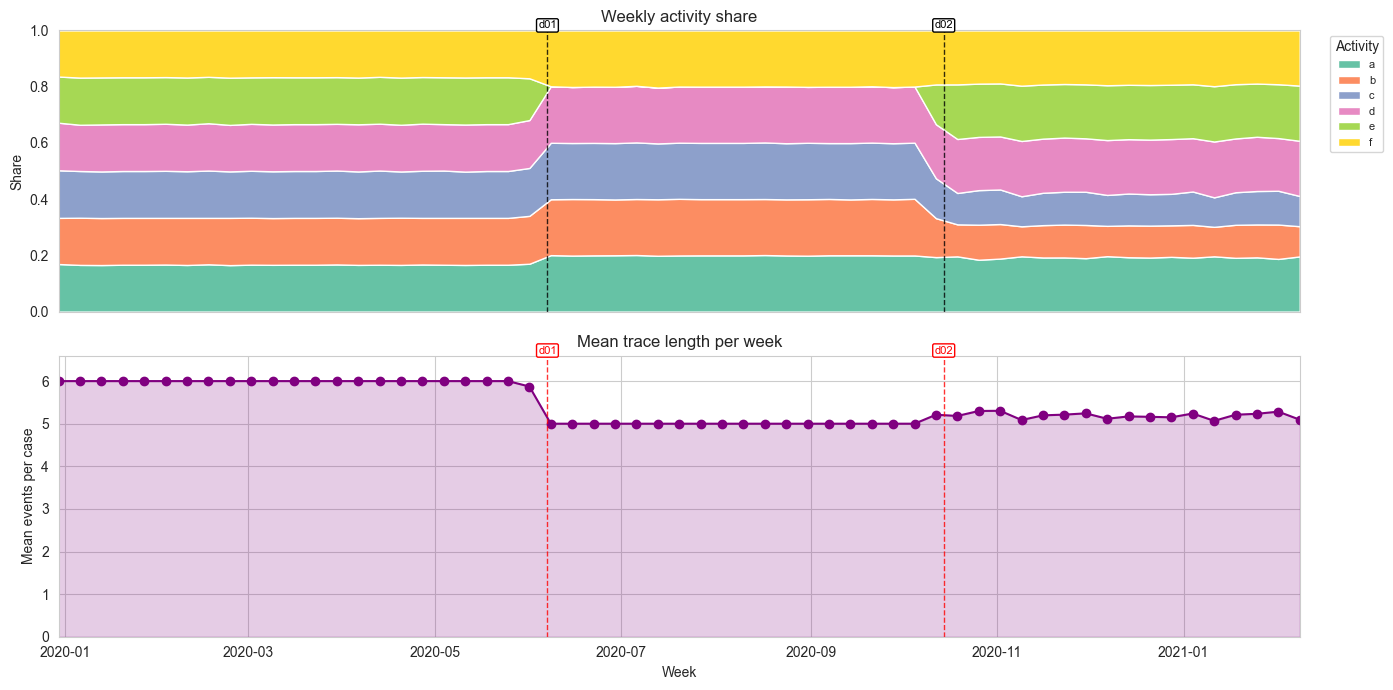

In [8]:
# Weekly activity share + mean trace length
weekly_activity = (
    df.groupby(["week", "activity"]).size()
    .unstack(fill_value=0)
    .reindex(columns=activities_sorted, fill_value=0)
    .sort_index()
)
weekly_activity_share = weekly_activity.div(weekly_activity.sum(axis=1), axis=0).fillna(0)

weekly_case_length = cases_df.groupby("week")["case_length"].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].stackplot(
    weekly_activity_share.index,
    weekly_activity_share.T.values,
    labels=weekly_activity_share.columns,
    colors=[ACTIVITY_COLORS[a] for a in weekly_activity_share.columns],
)
axes[0].set_title("Weekly activity share")
axes[0].set_ylabel("Share")
axes[0].set_ylim(0, 1)
axes[0].set_xlim(weekly_activity_share.index.min(), weekly_activity_share.index.max())
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Activity")
_draw_drift_lines(axes[0])

axes[1].plot(weekly_case_length.index, weekly_case_length.values,
             marker="o", color="purple", linewidth=1.5)
axes[1].fill_between(weekly_case_length.index, weekly_case_length.values,
                     alpha=0.2, color="purple")
axes[1].set_title("Mean trace length per week")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Mean events per case")
axes[1].set_ylim(0, weekly_case_length.max() * 1.1)
_draw_drift_lines(axes[1], color="red", label_color="red")

plt.tight_layout()
plt.show()

## 4 · Pre vs post — single comparison cell

Edit `SELECTED_DRIFT` to any timestamp (e.g. one of `DRIFT_TIMESTAMPS`) and
re-run the cell below. `WINDOW_DAYS` controls how many days on each side of
the drift are included. Cases are sliced by their **start timestamp**
(pre = case starts before drift, post = case starts at/after drift) so each
case stays whole. Pre on the left, post on the right, shared axes/colour
scales.

selected drift: 2020-06-06 21:37:28.876168+00:00  (±30d)
pre  window:    [2020-05-07 21:37:28.876168+00:00, 2020-06-06 21:37:28.876168+00:00)
post window:    [2020-06-06 21:37:28.876168+00:00, 2020-07-06 21:37:28.876168+00:00)
pre:  446 cases · 2,676 events · 1 variants
post: 446 cases · 2,230 events · 4 variants


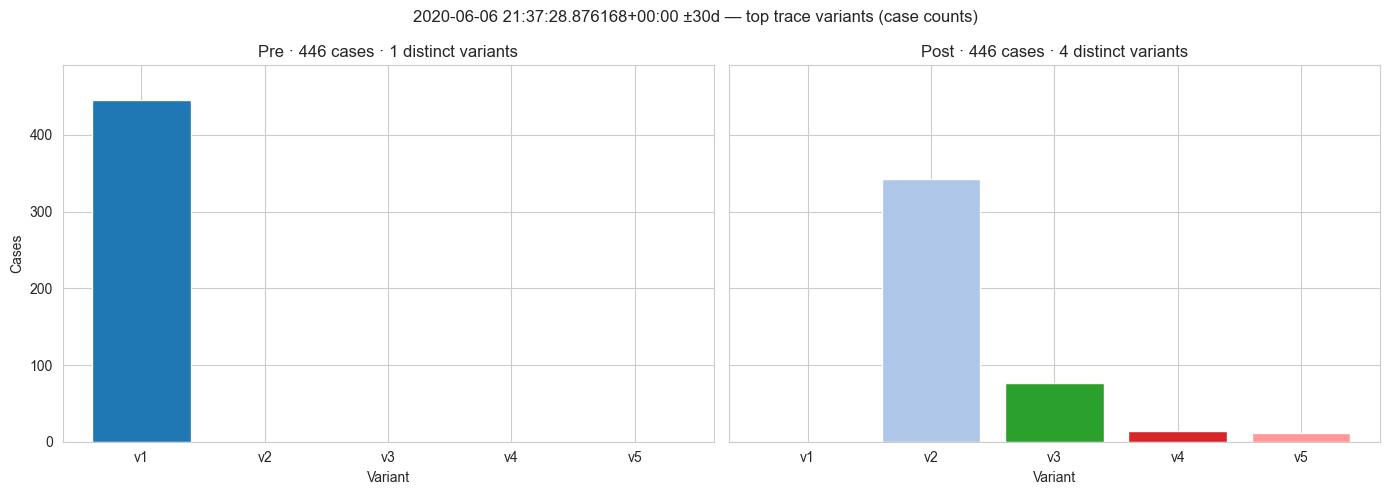

variant key:
  c,a,d,f,b,e: v1
  c,a,d,f,b: v2
  a,c,d,f,b: v3
  a,d,c,f,b: v4
  a,d,f,c,b: v5


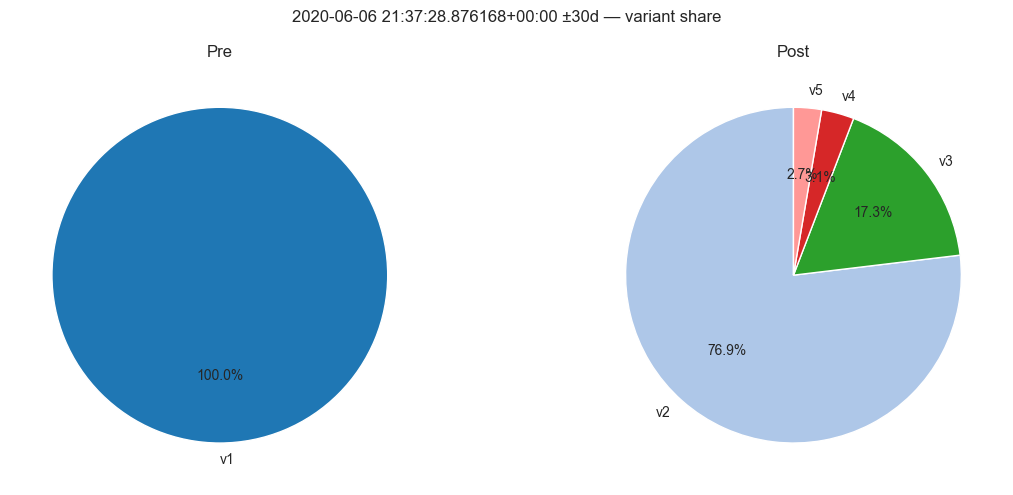

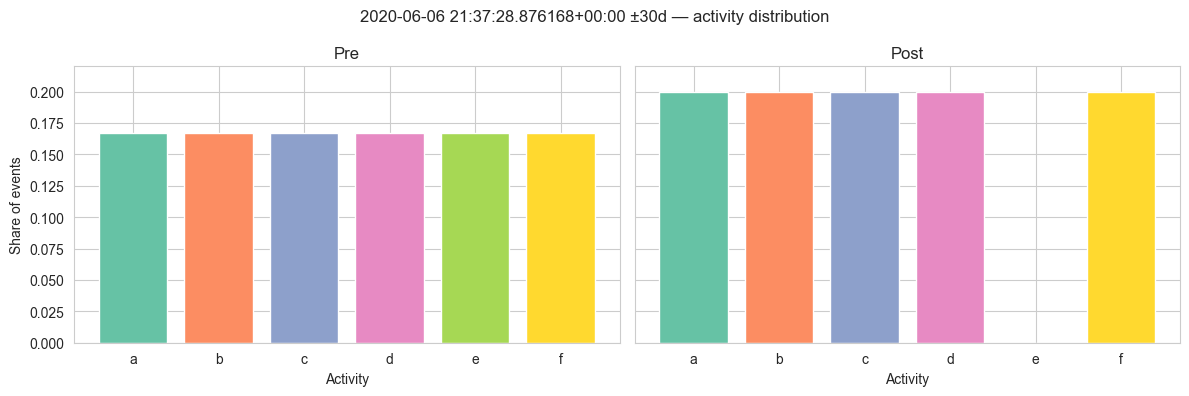

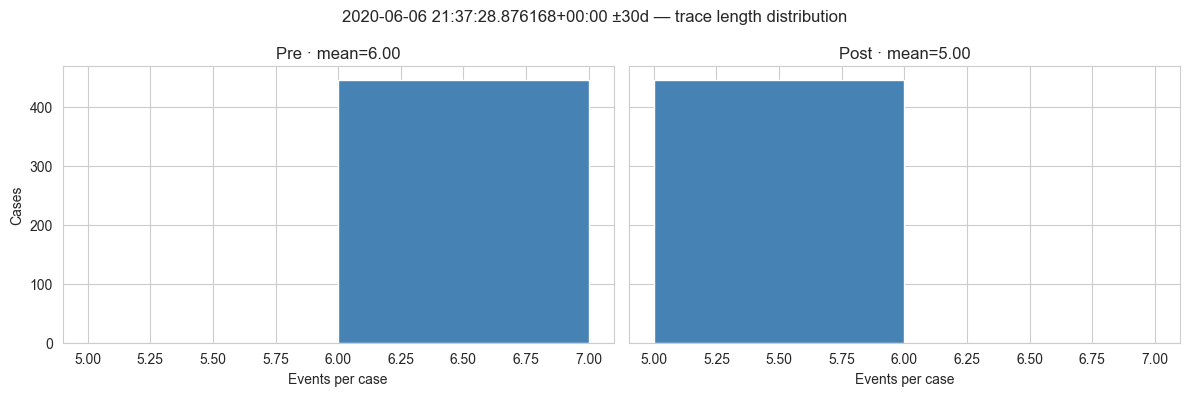

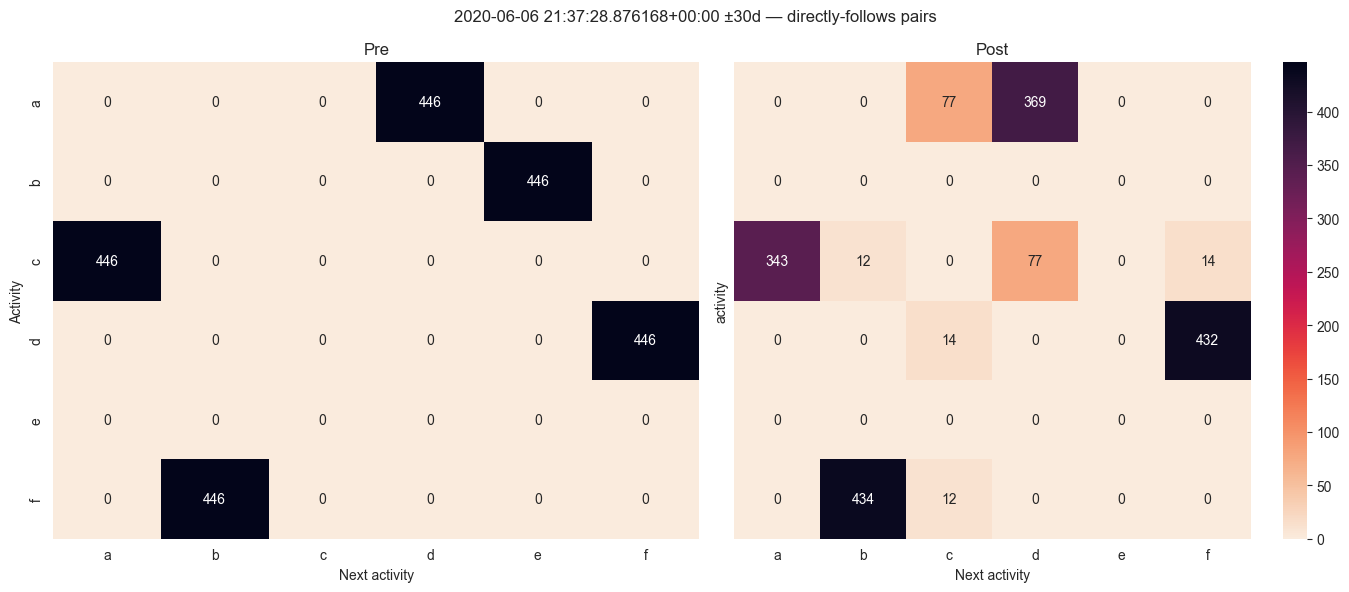

In [9]:
# === EDIT THESE TWO LINES ===
SELECTED_DRIFT = DRIFT_TIMESTAMPS[0]
WINDOW_DAYS = 30
# ============================

lo = SELECTED_DRIFT - pd.Timedelta(days=WINDOW_DAYS)
hi = SELECTED_DRIFT + pd.Timedelta(days=WINDOW_DAYS)

pre_cases = cases_df[(cases_df["case_start"] >= lo) & (cases_df["case_start"] < SELECTED_DRIFT)]
post_cases = cases_df[(cases_df["case_start"] >= SELECTED_DRIFT) & (cases_df["case_start"] < hi)]
pre = df[df["case_id"].isin(pre_cases["case_id"])]
post = df[df["case_id"].isin(post_cases["case_id"])]

print(f"selected drift: {SELECTED_DRIFT}  (±{WINDOW_DAYS}d)")
print(f"pre  window:    [{lo}, {SELECTED_DRIFT})")
print(f"post window:    [{SELECTED_DRIFT}, {hi})")
print(f"pre:  {len(pre_cases):,} cases · {len(pre):,} events · {pre_cases['variant'].nunique()} variants")
print(f"post: {len(post_cases):,} cases · {len(post):,} events · {post_cases['variant'].nunique()} variants")

# --- top trace variants ---
window_variants = pd.concat([pre_cases, post_cases])["variant"].value_counts().head(10).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
series = [sub["variant"].value_counts().reindex(window_variants, fill_value=0)
          for sub in (pre_cases, post_cases)]
ymax = max(s.max() for s in series) or 1
variant_short = {v: f"v{i + 1}" for i, v in enumerate(window_variants)}
for ax, c, title, sub in zip(axes, series, ["Pre", "Post"], [pre_cases, post_cases]):
    colors = [VARIANT_COLORS.get(v, "lightgray") for v in c.index]
    ax.bar([variant_short[v] for v in c.index], c.values, color=colors)
    ax.set_title(f"{title} · {len(sub):,} cases · {sub['variant'].nunique()} distinct variants")
    ax.set_xlabel("Variant")
axes[0].set_ylabel("Cases")
axes[0].set_ylim(0, ymax * 1.1)
fig.suptitle(f"{SELECTED_DRIFT} ±{WINDOW_DAYS}d — top trace variants (case counts)", fontsize=12)
plt.tight_layout()
plt.show()
print("variant key:")
for short, v in variant_short.items():
    print(f"  {short}: {v}")

# --- variant share pies ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, sub, title in zip(axes, [pre_cases, post_cases], ["Pre", "Post"]):
    vc = sub["variant"].value_counts()
    top_n = 6
    top = vc.head(top_n)
    other = vc.iloc[top_n:].sum()
    values = list(top.values) + ([other] if other > 0 else [])
    labels = [variant_short.get(v, f"…{i}") for i, v in enumerate(top.index)] + (
        ["other"] if other > 0 else []
    )
    colors = [VARIANT_COLORS.get(v, "lightgray") for v in top.index] + (
        ["lightgray"] if other > 0 else []
    )
    ax.pie(values, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
    ax.set_title(title)
fig.suptitle(f"{SELECTED_DRIFT} ±{WINDOW_DAYS}d — variant share", fontsize=12)
plt.tight_layout()
plt.show()

# --- activity distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
series = [sub["activity"].value_counts(normalize=True).reindex(activities_sorted, fill_value=0)
          for sub in (pre, post)]
ymax = max(s.max() for s in series) or 1
for ax, c, title in zip(axes, series, ["Pre", "Post"]):
    ax.bar(c.index, c.values, color=[ACTIVITY_COLORS[a] for a in c.index])
    ax.set_title(title)
    ax.set_xlabel("Activity")
axes[0].set_ylabel("Share of events")
axes[0].set_ylim(0, ymax * 1.1)
fig.suptitle(f"{SELECTED_DRIFT} ±{WINDOW_DAYS}d — activity distribution", fontsize=12)
plt.tight_layout()
plt.show()

# --- trace length distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
all_lengths = pd.concat([pre_cases["case_length"], post_cases["case_length"]])
bins = range(int(all_lengths.min()), int(all_lengths.max()) + 2)
for ax, sub, title in zip(axes, [pre_cases, post_cases], ["Pre", "Post"]):
    ax.hist(sub["case_length"], bins=bins, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} · mean={sub['case_length'].mean():.2f}")
    ax.set_xlabel("Events per case")
axes[0].set_ylabel("Cases")
fig.suptitle(f"{SELECTED_DRIFT} ±{WINDOW_DAYS}d — trace length distribution", fontsize=12)
plt.tight_layout()
plt.show()

# --- directly-follows heatmaps ---
def _dfg(sub):
    s = sub.copy()
    s["next_activity"] = s.groupby("case_id")["activity"].shift(-1)
    pairs = s.dropna(subset=["next_activity"])
    return pd.crosstab(pairs["activity"], pairs["next_activity"]).reindex(
        index=activities_sorted, columns=activities_sorted, fill_value=0
    )

pre_dfg = _dfg(pre)
post_dfg = _dfg(post)
vmax = max(pre_dfg.values.max(), post_dfg.values.max()) or 1
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
sns.heatmap(pre_dfg, annot=True, fmt="d", cmap="rocket_r",
            vmin=0, vmax=vmax, ax=axes[0], cbar=False)
axes[0].set_title("Pre")
axes[0].set_xlabel("Next activity")
axes[0].set_ylabel("Activity")
sns.heatmap(post_dfg, annot=True, fmt="d", cmap="rocket_r",
            vmin=0, vmax=vmax, ax=axes[1])
axes[1].set_title("Post")
axes[1].set_xlabel("Next activity")
fig.suptitle(f"{SELECTED_DRIFT} ±{WINDOW_DAYS}d — directly-follows pairs", fontsize=12)
plt.tight_layout()
plt.show()